# Smoking & Drinking Detection — **Finalized YOLOv8n Model**

This notebook contains **only the finished model**: the tuned **YOLOv8n** loaded from your
`yolov8n_best.pt` (trained 80 epochs on the full dataset with the winning hyperparameters), plus the
locked-in best parameters. No tuning, no training, no dataset prep — just load the model and detect.

**Classes:** `smoking (0)`, `drinking (1)` &nbsp;|&nbsp; **Input size:** 640×640

### Finalized best hyperparameters (for the record)
| Parameter | Value |
|---|---|
| model | yolov8n |
| lr0 | 0.001 |
| optimizer | AdamW |
| cos_lr | True |
| close_mosaic | 10 |
| imgsz | 640 |
| epochs | 80 |
| batch | 16 |
| seed | 42 |
| selected trial | t3_lr001_adamw |

## 1 · Setup

In [3]:
%pip -q install "ultralytics>=8.3.0" pyyaml matplotlib >/dev/null 2>&1

from pathlib import Path
import yaml
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Device: Tesla T4


## 2 · Load the finalized weights (upload via the left Files panel)

Open the **Files** panel on the left of Colab (the folder icon), and **drag your files into
`/content`** — no Drive needed. You can upload either:

* the **zip** you downloaded (`m4_yolov8n_best_weights.zip`) — it will be **unzipped automatically**, or
* the loose **`yolov8n_best.pt`** (and optionally `best_hyperparameters.yaml`).

Then run the cell below. Tip: if you upload while a cell is running, re-run this cell afterwards.

In [4]:
from pathlib import Path
import zipfile

CONTENT = Path("/content")

# 1) If a zip bundle was uploaded to /content, unzip it (looks for one containing a .pt)
for z in sorted(CONTENT.glob("*.zip")):
    try:
        with zipfile.ZipFile(z) as zf:
            if any(n.lower().endswith(".pt") for n in zf.namelist()):
                zf.extractall(CONTENT)
                print("Unzipped:", z.name)
    except zipfile.BadZipFile:
        print("Skipped (not a valid zip):", z.name)

# 2) locate the weights (.pt) anywhere under /content
def _find(pattern):
    hits = [p for p in CONTENT.rglob(pattern) if p.is_file()]
    return sorted(hits, key=lambda p: len(str(p)))[0] if hits else None

weights = _find("yolov8n_best.pt") or _find("best.pt") or _find("*.pt")
assert weights is not None, (
    "No .pt found in /content. Drag yolov8n_best.pt (or the zip) into the left Files panel, "
    "then re-run this cell.")

model = YOLO(str(weights))
print("Loaded finalized model from:", weights)
print("Classes:", model.names)
model.info()

Unzipped: m4_yolov8n_best_weights.zip
Loaded finalized model from: /content/yolov8n_best.pt
Classes: {0: 'smoking', 1: 'drinking'}
Model summary: 130 layers, 3,011,238 parameters, 0 gradients, 8.2 GFLOPs


(130, 3011238, 0, 8.192768)

## 3 · Confirm the finalized best parameters
Reads `best_hyperparameters.yaml` if you uploaded it (or if it came out of the zip); otherwise shows
the locked-in values.

In [5]:
import yaml

yml = _find("best_hyperparameters.yaml") or _find("*hyperparameters*.yaml")
if yml is not None:
    FINAL_PARAMS = yaml.safe_load(Path(yml).read_text())
    print("Loaded params from:", yml)
    print("\nLoaded hyperparameters:")
    for k, v in FINAL_PARAMS.items():
        print(f"  {k:16s}: {v}")

Loaded params from: /content/best_hyperparameters.yaml

Loaded hyperparameters:
  model           : yolov8n
  imgsz           : 640
  epochs          : 80
  batch           : 16
  seed            : 42
  selected_trial  : t3_lr001_adamw
  lr0             : 0.001
  optimizer       : AdamW
  cos_lr          : True
  close_mosaic    : 10


## 4 · Detect — run the model on your images
Upload your test image(s) into `/content` via the left **Files** panel, then run this cell
(or set `SOURCE` to a specific image/folder path).

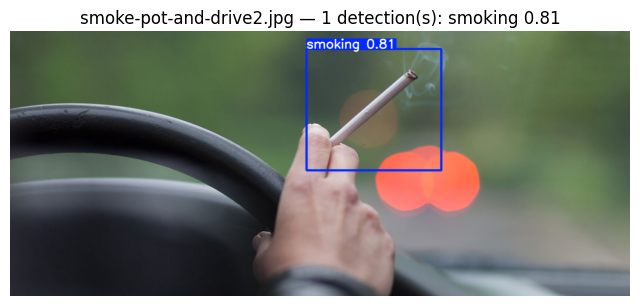

In [6]:
SOURCE = None          # e.g. "/content/my_photo.jpg" or "/content/test_pics"
CONF   = 0.25          # confidence threshold
_EXTS  = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

if SOURCE:
    p = Path(SOURCE)
    paths = [p] if p.is_file() else sorted(q for q in p.glob("*.*") if q.suffix.lower() in _EXTS)
else:
    # auto-collect images uploaded to /content (skip Colab's sample_data + any run outputs)
    paths = sorted(q for q in CONTENT.rglob("*")
                   if q.suffix.lower() in _EXTS and "sample_data" not in str(q)
                   and "runs" not in str(q) and "predictions" not in str(q))

assert paths, ("No images found in /content. Drag image(s) into the left Files panel, then re-run.")

for img in paths:
    res = model.predict(source=str(img), imgsz=640, conf=CONF, device=DEVICE, verbose=False)[0]
    annotated = res.plot()[:, :, ::-1]     # BGR → RGB
    labels = [f"{model.names[int(b.cls)]} {float(b.conf):.2f}" for b in res.boxes]
    plt.figure(figsize=(8, 8)); plt.imshow(annotated); plt.axis("off")
    plt.title(f"{img.name} — {len(res.boxes)} detection(s): " + (", ".join(labels) if labels else "none"))
    plt.show()

## 5 · (Optional) Save annotated results
Writes annotated images to a folder and, on Colab, downloads them.

In [7]:
OUT = Path("/content/predictions"); OUT.mkdir(exist_ok=True)
import cv2
saved = []
for img in paths:
    res = model.predict(source=str(img), imgsz=640, conf=CONF, device=DEVICE, verbose=False)[0]
    dst = OUT / f"pred_{Path(img).name}"
    cv2.imwrite(str(dst), res.plot()); saved.append(dst)
print("Saved annotated images to:", OUT)
for s in saved: print("  ", s)
# (You can also download them from the left Files panel: /content/predictions)

Saved annotated images to: /content/predictions
   /content/predictions/pred_smoke-pot-and-drive2.jpg


## 6 · Detect on video

Upload your test video into `/content` via the left **Files** panel, then run this cell
(or set `VIDEO_SOURCE` to a specific video path).

In [8]:
from pathlib import Path
CONTENT = Path("/content")

VIDEO_SOURCE = None # e.g. "/content/my_video.mp4"

if VIDEO_SOURCE:
    video_path = Path(VIDEO_SOURCE)
    assert video_path.is_file(), f"Video file not found at: {video_path}"
else:
    # Auto-collect videos uploaded to /content (skip Colab's sample_data + any run outputs)
    _VIDEO_EXTS = (".mp4", ".avi", ".mov", ".mkv")
    video_paths = sorted(q for q in CONTENT.rglob("*")
                       if q.suffix.lower() in _VIDEO_EXTS and "sample_data" not in str(q)
                       and "runs" not in str(q) and "predictions" not in str(q))
    if video_paths:
        video_path = video_paths[0] # Take the first found video
    else:
        raise AssertionError("No video found in /content. Drag video(s) into the left Files panel, then re-run.")

print(f"Processing video: {video_path.name}")

# Run inference on the video with stream=True to prevent out-of-memory errors on large videos.
# We then iterate through the generator to ensure all frames are processed and saved.
results = model.predict(source=str(video_path), imgsz=640, conf=CONF, device=DEVICE, show=False, save=True, stream=True, verbose=False)
for _ in results: # Iterate through results to trigger processing and saving frame by frame
    pass

print("Video detection complete. Output video(s) are saved in the 'runs' directory.")
print("You can find them in the 'Files' panel on the left (folder icon).")

Processing video: 9531460-uhd_4096_2160_25fps.mp4
Results saved to /content/runs/detect/predict-3
Video detection complete. Output video(s) are saved in the 'runs' directory.
You can find them in the 'Files' panel on the left (folder icon).


### View the output directory

By default, the `model.predict` saves the results in a `runs/detect/predictX` folder.
You can inspect the contents of that folder using shell commands:

In [9]:
from IPython.display import FileLink, display
from pathlib import Path

output_base_dir = Path('runs/detect')

# Define video extensions again to ensure availability, as they are defined in another cell.
_VIDEO_EXTS = (".mp4", ".avi", ".mov", ".mkv")

if not output_base_dir.exists():
    print(f"Error: Output directory '{output_base_dir}' not found.")
    print("It seems the model.predict command did not create the output files as expected.")
    print("Please ensure the previous cell (model.predict) executed successfully and check its output.")
elif not any(output_base_dir.iterdir()): # Check if the directory is empty
    print(f"Output directory '{output_base_dir}' is empty.")
    print("This might indicate that the model ran but did not save any predictions, or saved them under a different name.")
else:
    print(f"Contents of {output_base_dir}:")
    !ls -F {output_base_dir}

    # Try to get a direct link to the latest output video
    latest_run_dirs = sorted(output_base_dir.glob('predict*'))

    if latest_run_dirs:
        latest_run_dir = latest_run_dirs[-1]
        output_video = None
        for ext in _VIDEO_EXTS:
            found_video = next(latest_run_dir.glob(f'*{ext}'), None)
            if found_video:
                output_video = found_video
                break

        if output_video:
            print(f"\nDirect link to output video: {output_video}")
            display(FileLink(str(output_video)))
        else:
            print(f"No video file with extensions {_VIDEO_EXTS} found in the latest prediction run directory: {latest_run_dir}.")
            print(f"You can inspect its contents using: !ls -F {latest_run_dir}")
    else:
        print(f"No 'predict*' subdirectories found in {output_base_dir}.")
        print("This might indicate that the model ran but did not save any predictions, or saved them under a different name.")

Contents of runs/detect:
predict/  predict-2/  predict-3/

Direct link to output video: runs/detect/predict-3/9531460-uhd_4096_2160_25fps.avi


/content/runs/detect/predict-3/9531460-uhd_4096_2160_25fps.avi